<a href="https://colab.research.google.com/github/dohaalnabahin/Data_science_and_machine_learning_Journey/blob/main/Stakeholder_Questions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Part1_Crime_Beta_3880953751259285714.csv",
)

df.head()

/tmp/ipykernel_588/1588594107.py:3: DtypeWarning: Columns (5,7,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,RowID,CCNumber,CrimeDateTime,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,...,Old_District,New_District,Neighborhood,Latitude,Longitude,GeoLocation,PremiseType,Total_Incidents,x,y
0,1,14I10336,8/29/2014 12:00:00 PM,5A,BURGLARY,NaN,NaN,835.0,M,52.0,...,SOUTHWEST,NaN,SHIPLEY HILL,39.288352,-76.660731,"(39.288352111548775,-76.660731200606335)",ROW/TOWNHOUSE-VAC,1,-76.660731,39.288352
1,2,14H13075,8/29/2014 11:45:00 PM,4E,COMMON ASSAULT,NaN,NaN,515.0,F,24.0,...,NORTHERN,NaN,WAVERLY,39.335514,-76.607897,"(39.335514488267016,-76.60789683728612)",ROW/TOWNHOUSE-OCC,1,-76.607897,39.335514
2,3,14H13066,8/29/2014 11:10:00 PM,6G,LARCENY,NaN,NaN,114.0,F,44.0,...,CENTRAL,NaN,DOWNTOWN,39.292553,-76.618255,"(39.292552601970897,-76.618254674552134)",BAR,1,-76.618255,39.292553
3,4,14I00593,8/29/2014 7:00:00 AM,6J,LARCENY,NaN,NaN,732.0,NaN,NaN,...,WESTERN,NaN,PARKVIEW/WOODBROOK,39.316814,-76.649890,"(39.316813840390076,-76.649889876952656)",STREET,1,-76.649890,39.316814
4,5,14H13360,8/29/2014 11:30:00 PM,6G,LARCENY,NaN,NaN,213.0,F,26.0,...,SOUTHEAST,NaN,FELLS POINT,39.280805,-76.594750,"(39.28080478810265,-76.594749640946659)",BAR,1,-76.594750,39.280805


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install holidays -q
from holidays import country_holidays

if "CrimeDateTime" in df.columns:
    df["CrimeDateTime"] = pd.to_datetime(df["CrimeDateTime"], errors="coerce")
    df = df.dropna(subset=["CrimeDateTime"])
    df = df.set_index("CrimeDateTime").sort_index()
else:
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()].sort_index()

df = df.loc["2011":"2022"].copy()

if "Total_Incidents" not in df.columns:
    df["Total_Incidents"] = 1

df["Date"] = df.index.date
df["Year"] = df.index.year
df["Month"] = df.index.month
df["MonthName"] = df.index.month_name()
df["DayOfWeek"] = df.index.day_name()
df["DayNum"] = df.index.day_of_week
df["HourOfDay"] = df.index.hour

us_holidays = country_holidays("US")
df["US Holiday"] = [us_holidays.get(day) for day in df["Date"]]
df["Is_Holiday"] = df["US Holiday"].notna()

df.head()

,RowID,CCNumber,CrimeCode,Description,Inside_Outside,Weapon,Post,Gender,Age,Race,...,y,Date,Year,Month,MonthName,DayOfWeek,DayNum,HourOfDay,US Holiday,Is_Holiday
CrimeDateTime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,148268,11A01127,6G,LARCENY,NaN,NaN,942.0,F,26.0,WHITE,...,39.277040,2011-01-01,2011,1,January,Saturday,5,0,New Year's Day,True
2011-01-01 00:00:00,150410,11A01120,6E,LARCENY,NaN,NaN,721.0,M,44.0,BLACK_OR_AFRICAN_AMERICAN,...,39.295738,2011-01-01,2011,1,January,Saturday,5,0,New Year's Day,True
2011-01-01 00:00:00,150030,19I04219,2A,RAPE,NaN,OTHER,724.0,M,16.0,BLACK_OR_AFRICAN_AMERICAN,...,39.298875,2011-01-01,2011,1,January,Saturday,5,0,New Year's Day,True
2011-01-01 00:01:00,148093,11A00683,6J,LARCENY,NaN,NaN,942.0,M,24.0,WHITE,...,39.274925,2011-01-01,2011,1,January,Saturday,5,0,New Year's Day,True
2011-01-01 00:01:00,150408,13F02687,6G,LARCENY,NaN,NaN,233.0,NaN,NaN,UNKNOWN,...,39.284338,2011-01-01,2011,1,January,Saturday,5,0,New Year's Day,True


#**Q1) What is the likelihood of each crime across hours of the day?**

In [8]:
# counts حسب نوع الجريمة والساعة
val_counts_by_hour = df.groupby("Description")["HourOfDay"].value_counts()

# percent حسب نوع الجريمة والساعة
crime_perc_by_hour = df.groupby("Description")["HourOfDay"].value_counts(normalize=True)

q1_rows = []

for crime in val_counts_by_hour.index.get_level_values(0).unique():
    counts = val_counts_by_hour.loc[crime]
    perc = crime_perc_by_hour.loc[crime]

    min_hour = counts.idxmin()
    max_hour = counts.idxmax()

    q1_rows.append({
        "Crime": crime,
        "Most Likely Hour": max_hour,
        "Max Count": counts.loc[max_hour],
        "Max Percent": perc.loc[max_hour] * 100,
        "Least Likely Hour": min_hour,
        "Min Count": counts.loc[min_hour],
        "Min Percent": perc.loc[min_hour] * 100
    })

q1_answer = pd.DataFrame(q1_rows).sort_values("Crime")
q1_answer

,Crime,Most Likely Hour,Max Count,Max Percent,Least Likely Hour,Min Count,Min Percent
0,AGG. ASSAULT,21,4030,6.394389,6,775,1.229690
1,ARSON,1,184,7.556468,7,56,2.299795
2,AUTO THEFT,22,3547,7.649177,4,693,1.494469
3,BURGLARY,12,4726,6.127715,5,1887,2.446677
4,COMMON ASSAULT,15,5784,5.813124,6,1276,1.282425
5,HOMICIDE,21,249,7.488722,5,38,1.142857
6,LARCENY,12,8777,7.151704,4,1136,0.925639
7,LARCENY FROM AUTO,18,5336,7.549519,4,900,1.273345
8,RAPE,0,442,12.129528,9,73,2.003293
9,ROBBERY,23,3091,7.075169,7,696,1.593115


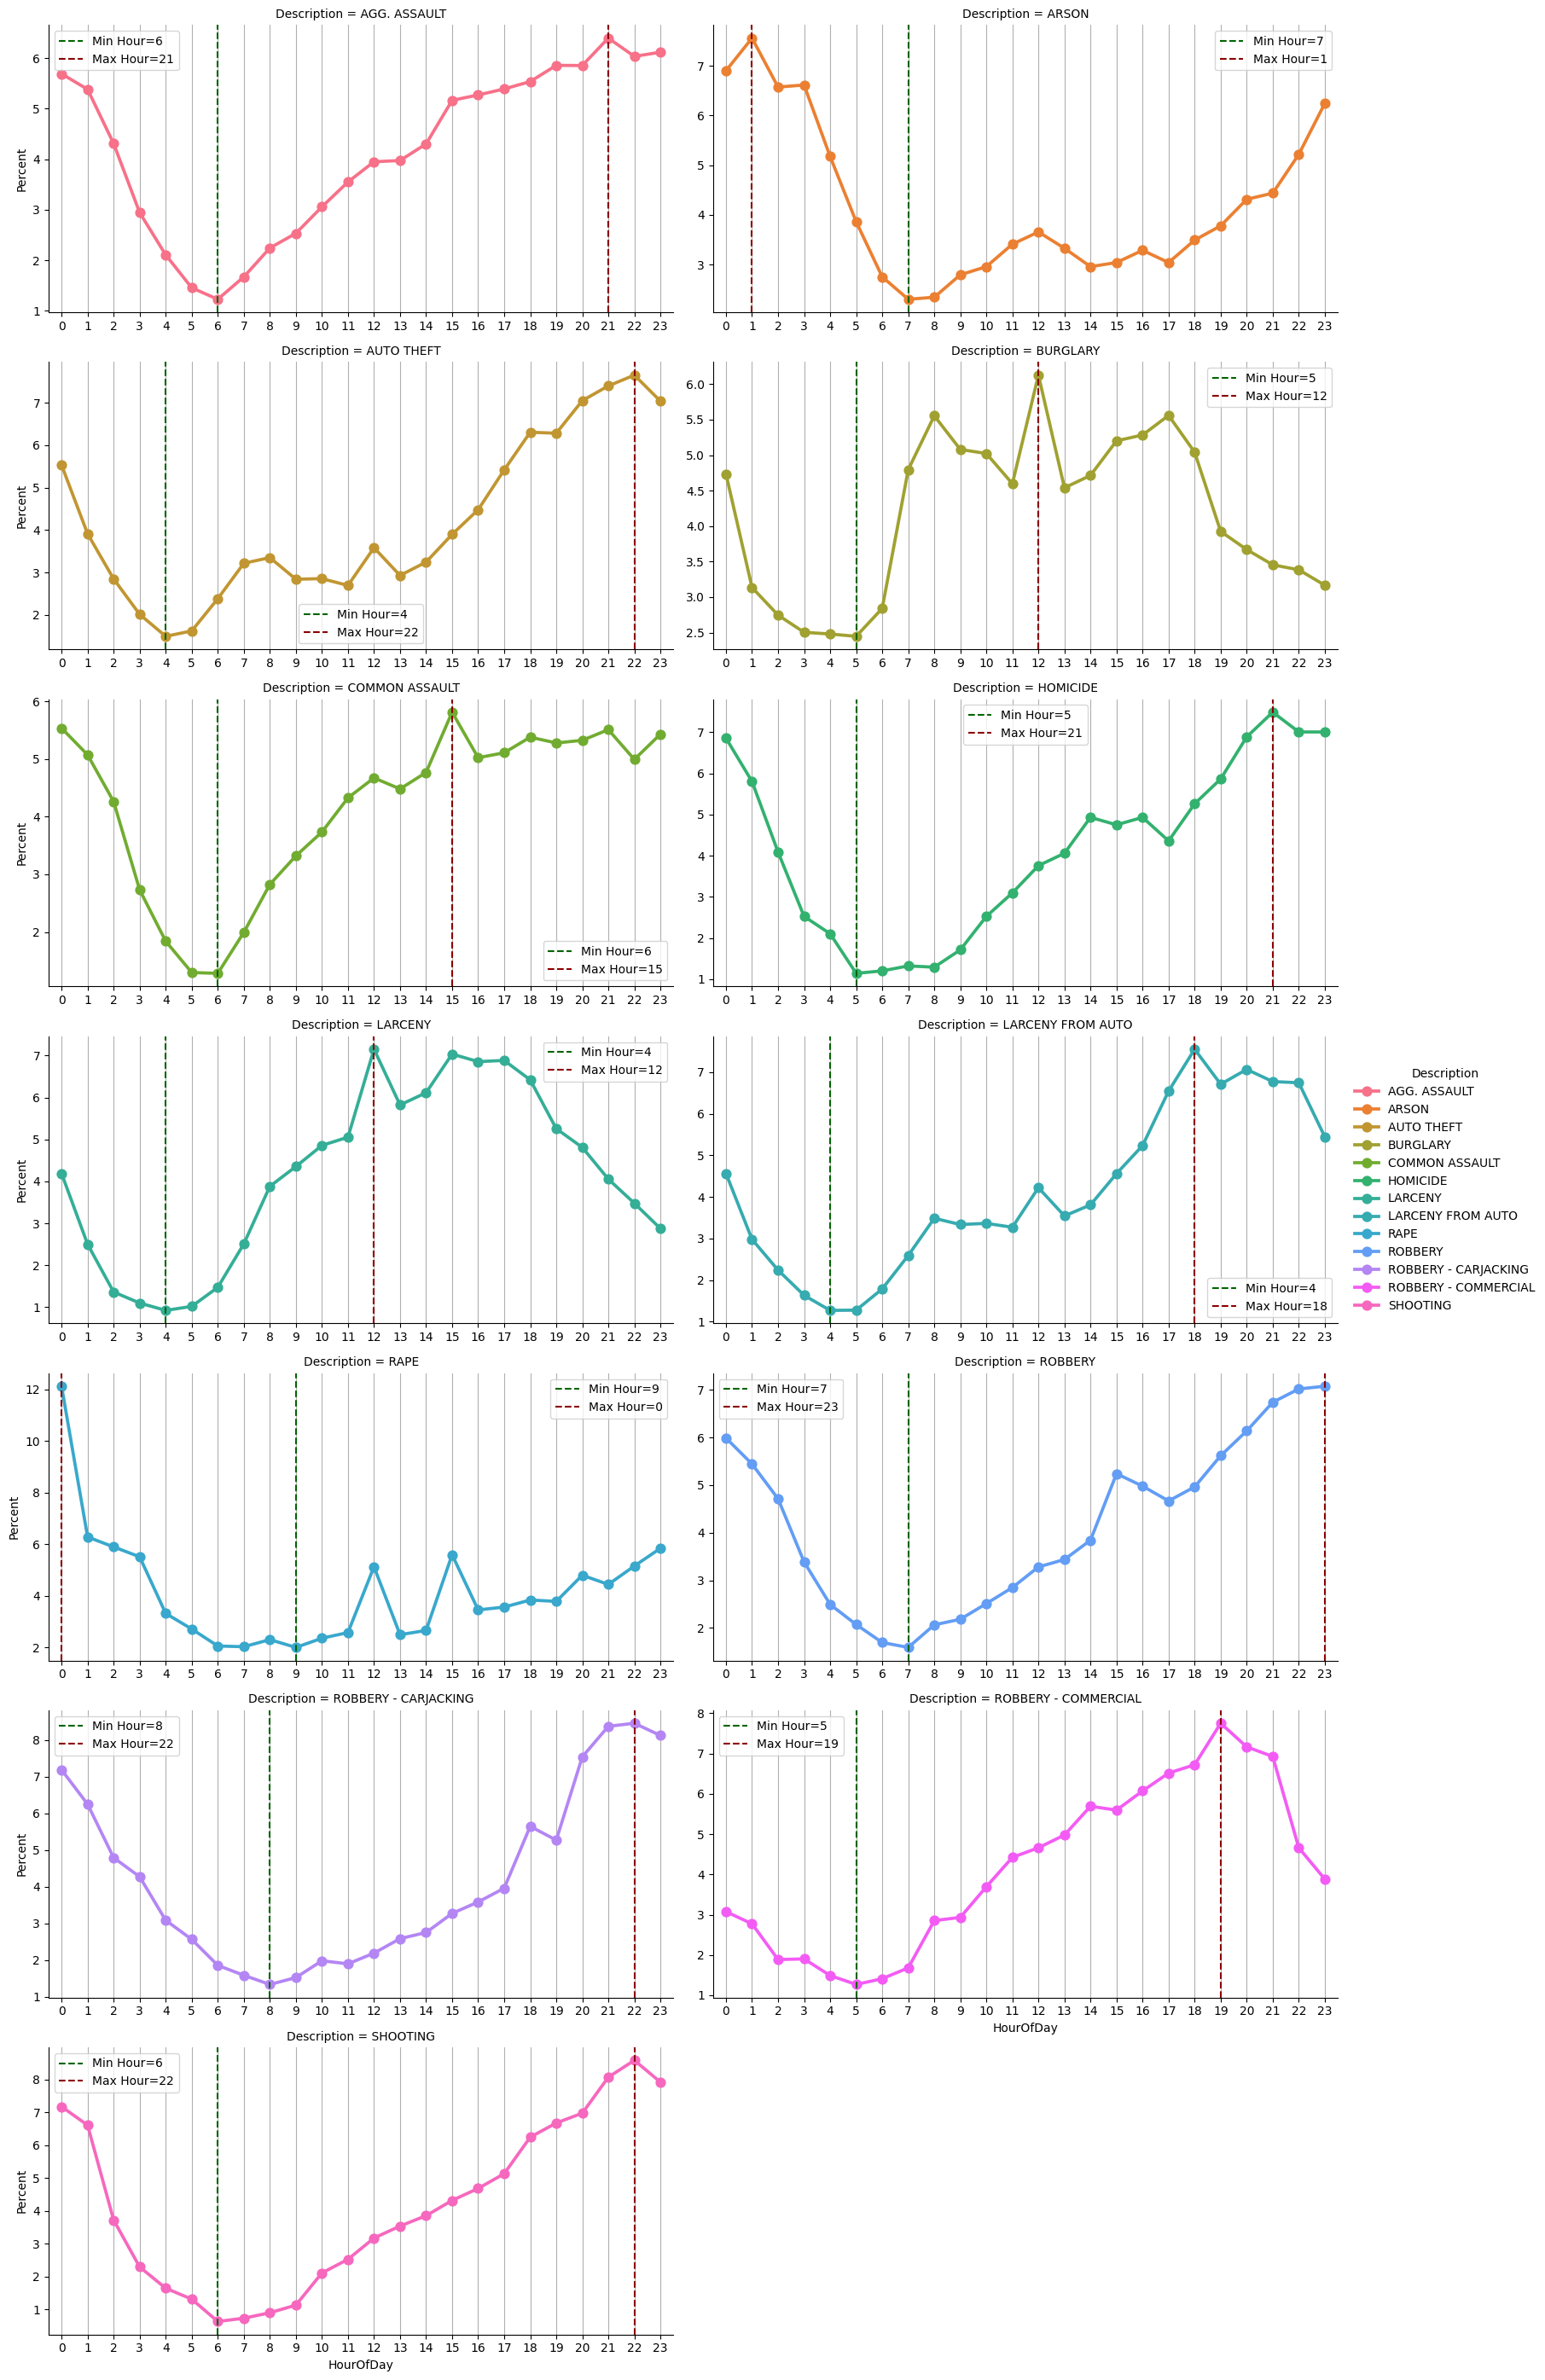

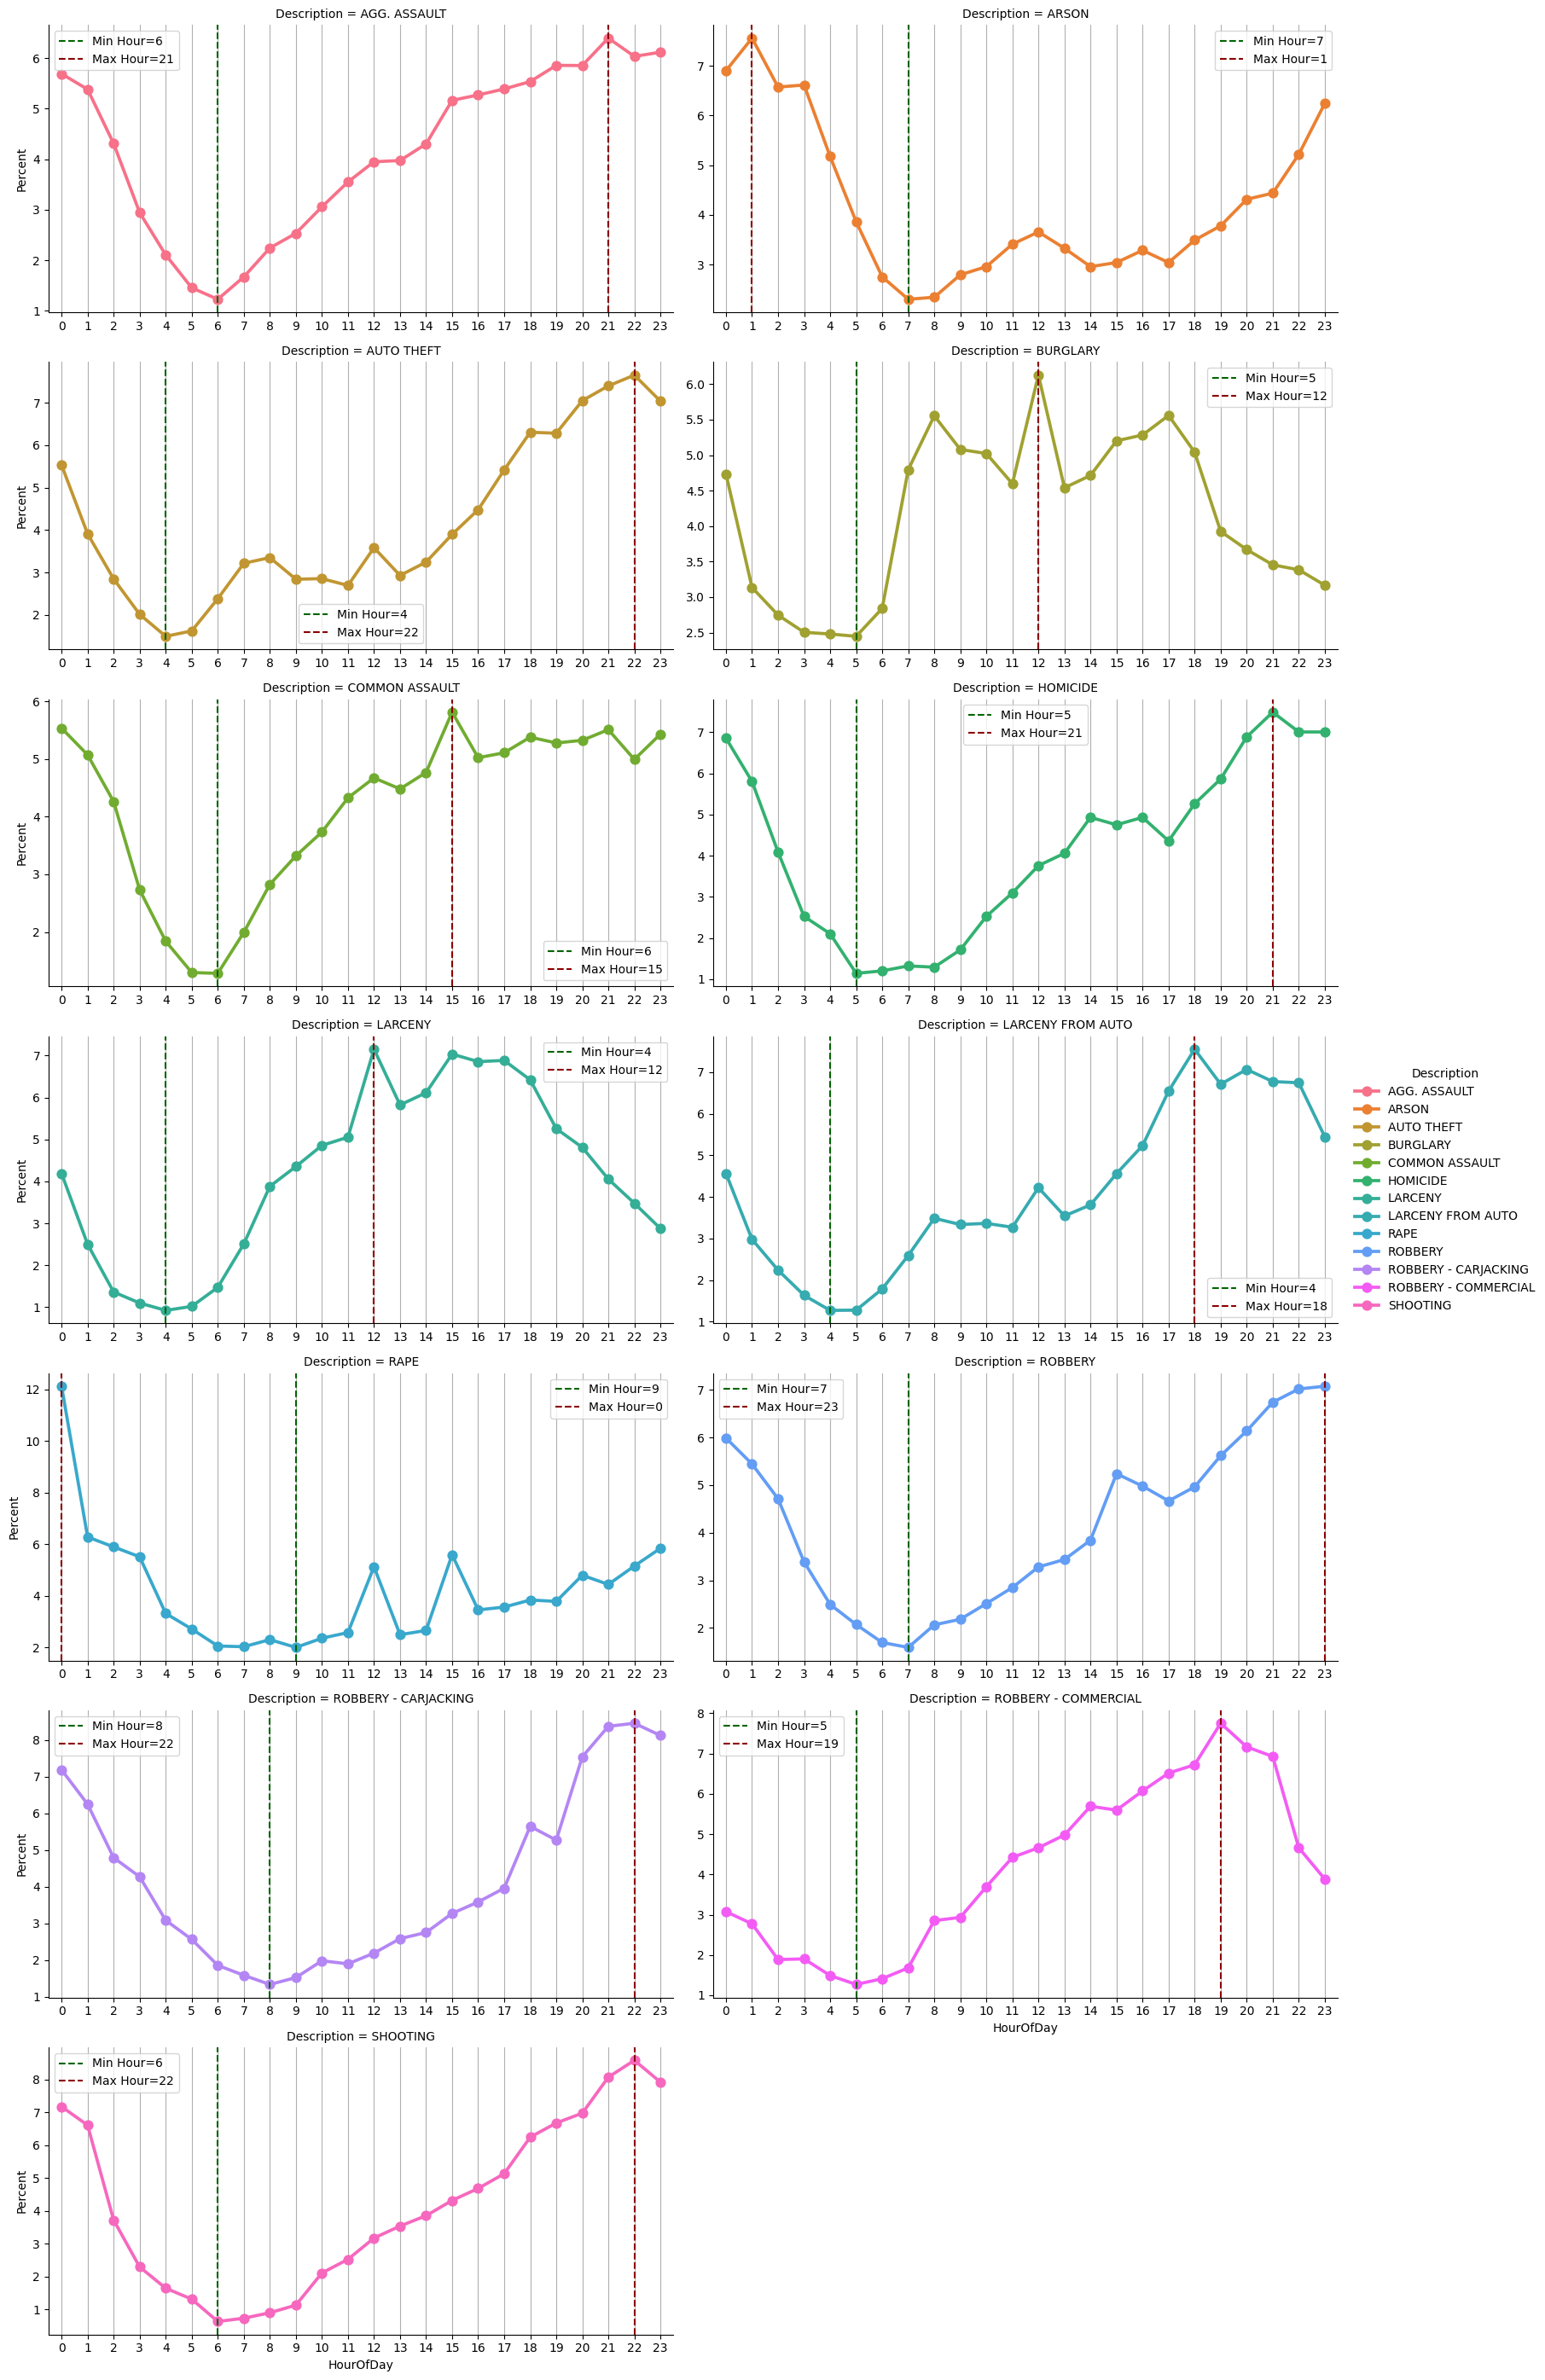

In [9]:
plot_df_perc = crime_perc_by_hour.to_frame("Percent").reset_index()
plot_df_perc["Percent"] = plot_df_perc["Percent"] * 100

g = sns.catplot(
    data=plot_df_perc,
    x="HourOfDay",
    y="Percent",
    hue="Description",
    col="Description",
    col_wrap=2,
    kind="point",
    sharey=False,
    sharex=False,
    aspect=2,
    height=4
)

for col, ax in g.axes_dict.items():
    row = q1_answer[q1_answer["Crime"] == col].iloc[0]

    min_hour = row["Least Likely Hour"]
    max_hour = row["Most Likely Hour"]

    ln1 = ax.axvline(min_hour, color="darkgreen", ls="--")
    ln2 = ax.axvline(max_hour, color="darkred", ls="--")

    ax.legend([ln1, ln2], [f"Min Hour={min_hour}", f"Max Hour={max_hour}"])
    ax.grid(axis="x")

g.fig

### Q1: Crime Likelihood Across Hours of the Day

The hourly patterns show that most crimes are least likely to occur in the early morning hours, especially around 4 AM to 8 AM. Many crimes become more likely later in the day or at night. For example, robberies, shootings, auto theft, and carjacking tend to peak in the evening or late night. Some crimes have different patterns, such as burglary and larceny, which peak closer to daytime hours.

**Conclusion:** Crime patterns vary by type, but many crimes are lowest in the early morning and highest later in the day or at night.


#**Q2) What are the 3 most common crimes committed in**

In [10]:
crimes_by_month = df.groupby("Month")["Description"].value_counts()

jan_dec_crimes = crimes_by_month.loc[1].add(
    crimes_by_month.loc[12],
    fill_value=0
).sort_values(ascending=False)

top3_dec_jan = jan_dec_crimes.head(3)
top3_dec_jan

,count
Description,
LARCENY,19265
COMMON ASSAULT,15177
BURGLARY,13061


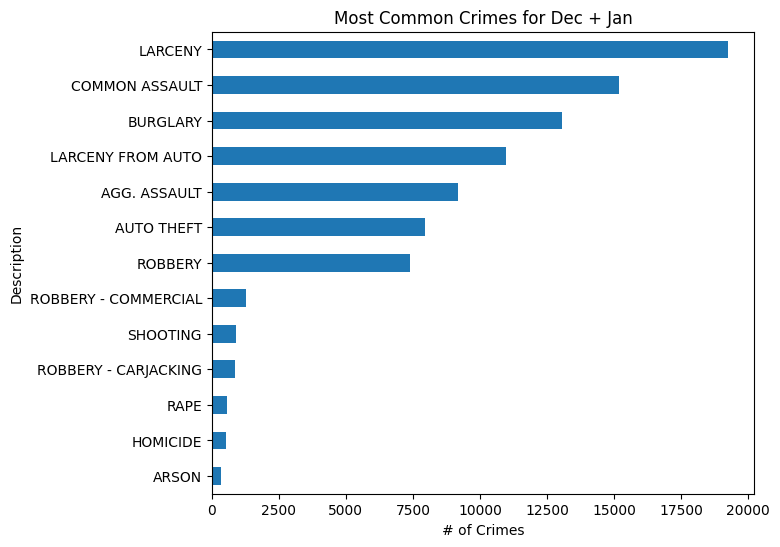

In [11]:
ax = jan_dec_crimes.sort_values().plot(kind="barh", figsize=(7, 6))
ax.set(title="Most Common Crimes for Dec + Jan", xlabel="# of Crimes")
plt.show()

### Q2: Most Common Crimes in December and January

The chart shows that the top three crimes during December and January are:

1. **Larceny**
2. **Common Assault**
3. **Burglary**

**Conclusion:** Larceny is the most common crime in December and January, followed by Common Assault and Burglary.


#**Q3) Are there crimes that are trending up/down? if you...:**

In [12]:
df_year = (
    df.groupby("Description")["Total_Incidents"]
    .resample("YE")
    .sum()
    .reset_index()
)

years_ts = df_year.pivot(
    index="CrimeDateTime",
    columns="Description",
    values="Total_Incidents"
)

delta_crime_yrs = years_ts.loc["2021-12-31"] - years_ts.loc["2018-12-31"]

delta_crime_yrs_sorted = delta_crime_yrs.sort_values()
delta_crime_yrs_sorted

,0
Description,
LARCENY,-3113.0
BURGLARY,-2739.0
LARCENY FROM AUTO,-2636.0
ROBBERY,-1669.0
AUTO THEFT,-1019.0
COMMON ASSAULT,-280.0
ROBBERY - COMMERCIAL,-76.0
RAPE,-73.0
ARSON,-8.0


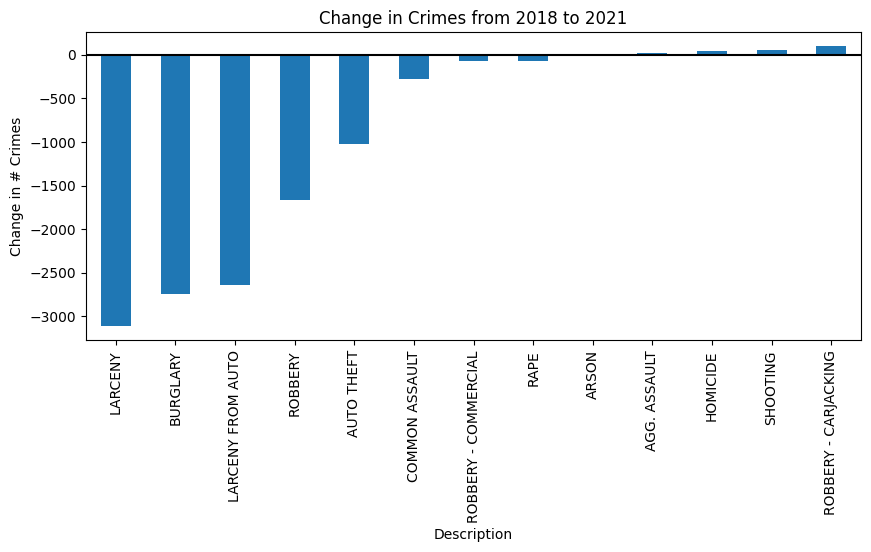

In [13]:
ax = delta_crime_yrs_sorted.plot(
    kind="bar",
    figsize=(10, 4),
    ylabel="Change in # Crimes",
    title="Change in Crimes from 2018 to 2021"
)
ax.axhline(0, color="black")
plt.show()

In [14]:
increased_counts = delta_crime_yrs[delta_crime_yrs > 0].sort_values(ascending=False)
decreased_counts = delta_crime_yrs[delta_crime_yrs < 0].sort_values()

print("Crimes increased:")
display(increased_counts)

print("Crimes decreased:")
display(decreased_counts)

Crimes increased:


,0
Description,
ROBBERY - CARJACKING,97.0
SHOOTING,49.0
HOMICIDE,37.0
AGG. ASSAULT,24.0


Crimes decreased:


,0
Description,
LARCENY,-3113.0
BURGLARY,-2739.0
LARCENY FROM AUTO,-2636.0
ROBBERY,-1669.0
AUTO THEFT,-1019.0
COMMON ASSAULT,-280.0
ROBBERY - COMMERCIAL,-76.0
RAPE,-73.0
ARSON,-8.0


In [15]:
delta_crime_perc = (delta_crime_yrs / years_ts.loc["2018-12-31"]) * 100

delta_crime_perc_sorted = delta_crime_perc.sort_values()
delta_crime_perc_sorted

,0
Description,
BURGLARY,-44.049534
LARCENY FROM AUTO,-41.336051
ROBBERY,-37.914584
LARCENY,-29.063579
AUTO THEFT,-24.164098
RAPE,-19.945355
ROBBERY - COMMERCIAL,-12.044374
ARSON,-6.299213
COMMON ASSAULT,-3.314394


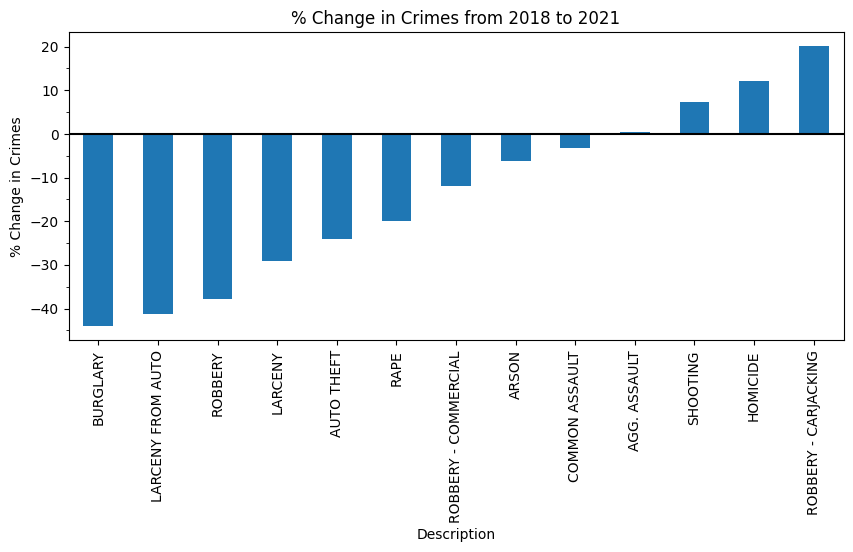

In [16]:
from matplotlib import ticker

ax = delta_crime_perc_sorted.plot(
    kind="bar",
    figsize=(10, 4),
    ylabel="% Change in Crimes",
    title="% Change in Crimes from 2018 to 2021"
)

ax.axhline(0, color="black")
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
plt.show()

### Q3: Percent Change in Crimes from 2018 to 2021

Most crime types decreased from 2018 to 2021. The largest decreases were in Burglary, Larceny from Auto, Robbery, and Larceny. However, some crimes increased, including Shooting, Homicide, and especially Robbery-Carjacking.

**Conclusion:** Overall crime decreased for most categories, but serious crimes like Shooting, Homicide, and Robbery-Carjacking increased.


#**Q4) What crimes are most common on New Year's Day?**

In [17]:
holiday_crimes = df.groupby("US Holiday")["Description"].value_counts()
holiday_crimes = holiday_crimes.to_frame("# of Crimes")

# نجمع New Year's Day مع New Year's Day (Observed)
new_year_labels = ["New Year's Day", "New Year's Day (Observed)"]

available_labels = [
    label for label in new_year_labels
    if label in holiday_crimes.index.get_level_values(0)
]

temp = pd.concat(
    [holiday_crimes.loc[label] for label in available_labels],
    axis=1
)

new_years_sum = temp.sum(axis=1).sort_values(ascending=False)

new_years_sum

,0
Description,
COMMON ASSAULT,379
LARCENY,371
AGG. ASSAULT,261
BURGLARY,219
LARCENY FROM AUTO,183
AUTO THEFT,126
ROBBERY,111
RAPE,64
SHOOTING,20


In [18]:
new_years_top5 = new_years_sum.head(5)
new_years_top5

,0
Description,
COMMON ASSAULT,379
LARCENY,371
AGG. ASSAULT,261
BURGLARY,219
LARCENY FROM AUTO,183


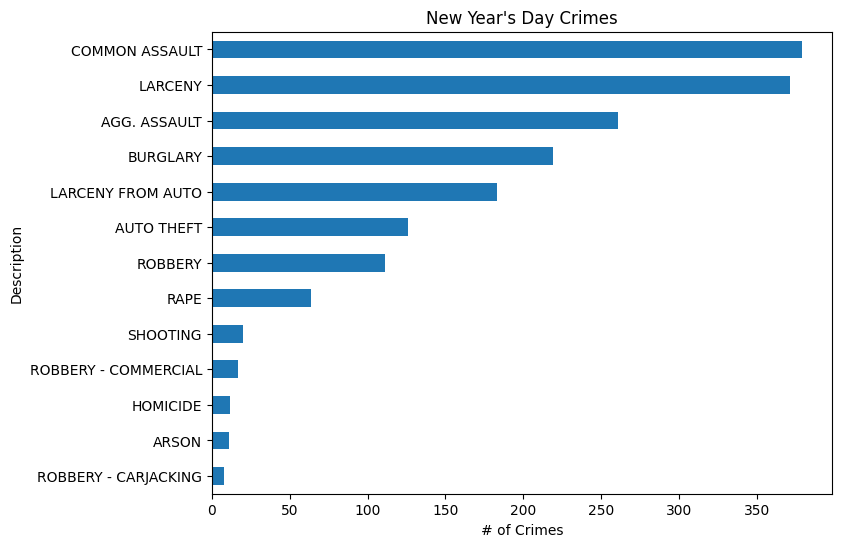

In [19]:
ax = new_years_sum.sort_values().plot(kind="barh", figsize=(8, 6))
ax.set(title="New Year's Day Crimes", xlabel="# of Crimes")
plt.show()

### Q4: Most Common Crimes on New Year's Day

The chart shows that the most common crimes on New Year's Day are:

1. **Common Assault**
2. **Larceny**
3. **Aggravated Assault**

**Conclusion:** Common Assault and Larceny are the most frequent crimes on New Year's Day.

#**Q5) Are there more crimes on Thanksgiving than on any other Thursday in the dataset? Thanksgiving VS Thursdays**

In [20]:
daily_df = (
    df.groupby("Description")["Total_Incidents"]
    .resample("D")
    .sum()
    .reset_index()
)

daily_df = daily_df.pivot(
    index="CrimeDateTime",
    columns="Description",
    values="Total_Incidents"
).fillna(0)

daily_df["TOTAL CRIME"] = daily_df.sum(axis=1)

us_holidays = country_holidays("US")

daily_df["DayOfWeek"] = daily_df.index.day_name()
daily_df["Holiday"] = daily_df.index.map(us_holidays.get)
daily_df["Holiday"] = daily_df["Holiday"].fillna("None")

is_thanks = daily_df["Holiday"].str.contains("thanksgiving", case=False)
is_thurs = daily_df["DayOfWeek"] == "Thursday"

plot_df = daily_df.copy()

plot_df.loc[is_thanks, "Group"] = "Thanksgiving"
plot_df.loc[~is_thanks & is_thurs, "Group"] = "Other Thursday"

thanksgiving_compare = plot_df.dropna(subset=["Group"]).groupby("Group")["TOTAL CRIME"].agg(["count", "mean", "median", "sum"])

thanksgiving_compare

,count,mean,median,sum
Group,,,,
Other Thursday,614,124.433225,126.0,76402.0
Thanksgiving,12,100.750000,100.5,1209.0


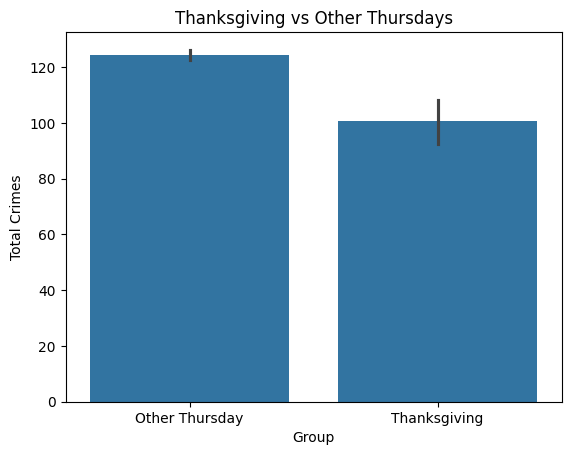

In [21]:
ax = sns.barplot(
    data=plot_df.dropna(subset=["Group"]),
    x="Group",
    y="TOTAL CRIME"
)

ax.set(title="Thanksgiving vs Other Thursdays", ylabel="Total Crimes")
plt.show()

In [22]:
thanks_mean = thanksgiving_compare.loc["Thanksgiving", "mean"]
other_thurs_mean = thanksgiving_compare.loc["Other Thursday", "mean"]

print(f"Thanksgiving average crimes: {thanks_mean:.2f}")
print(f"Other Thursdays average crimes: {other_thurs_mean:.2f}")

if thanks_mean > other_thurs_mean:
    print("Answer: Yes, Thanksgiving has more crimes on average.")
else:
    print("Answer: No, Thanksgiving has fewer crimes on average than other Thursdays.")

Thanksgiving average crimes: 100.75
Other Thursdays average crimes: 124.43
Answer: No, Thanksgiving has fewer crimes on average than other Thursdays.


### Q5: Thanksgiving vs Other Thursdays

Thanksgiving which is a U.S. holiday that occurs on a Thursday.  
The chart compares total crimes on Thanksgiving with other Thursdays in the dataset.

The result shows that Thanksgiving has fewer crimes on average than other Thursdays.

**Conclusion:** No, Thanksgiving does not have more crimes than other Thursdays. It has fewer crimes on average.